<a href="https://colab.research.google.com/github/PhuongAnh2212/capstone-project/blob/main/Traffic_Sign_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [11]:
# Import Essential Libraries
import os
import random
import pandas as pd
from PIL import Image
import cv2
from ultralytics import YOLO
from IPython.display import Video
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
import pathlib
import glob
from tqdm.notebook import trange, tqdm
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Configure the visual appearance of Seaborn plots
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/Capstone/Kaggle-VN-Road-Sign/traffic-sign.zip"  # Change this
extract_path = "/content/dataset"  # Folder where the dataset will be extracted

In [4]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check extracted files
print("Extracted files:", os.listdir(extract_path))

Extracted files: ['archive']


In [22]:
import shutil

folder_path = "/content/dataset/archive/split_dataset"

# Delete the folder and all its contents
shutil.rmtree(folder_path)

print(f"✅ Deleted: {folder_path}")

✅ Deleted: /content/dataset/archive/split_dataset


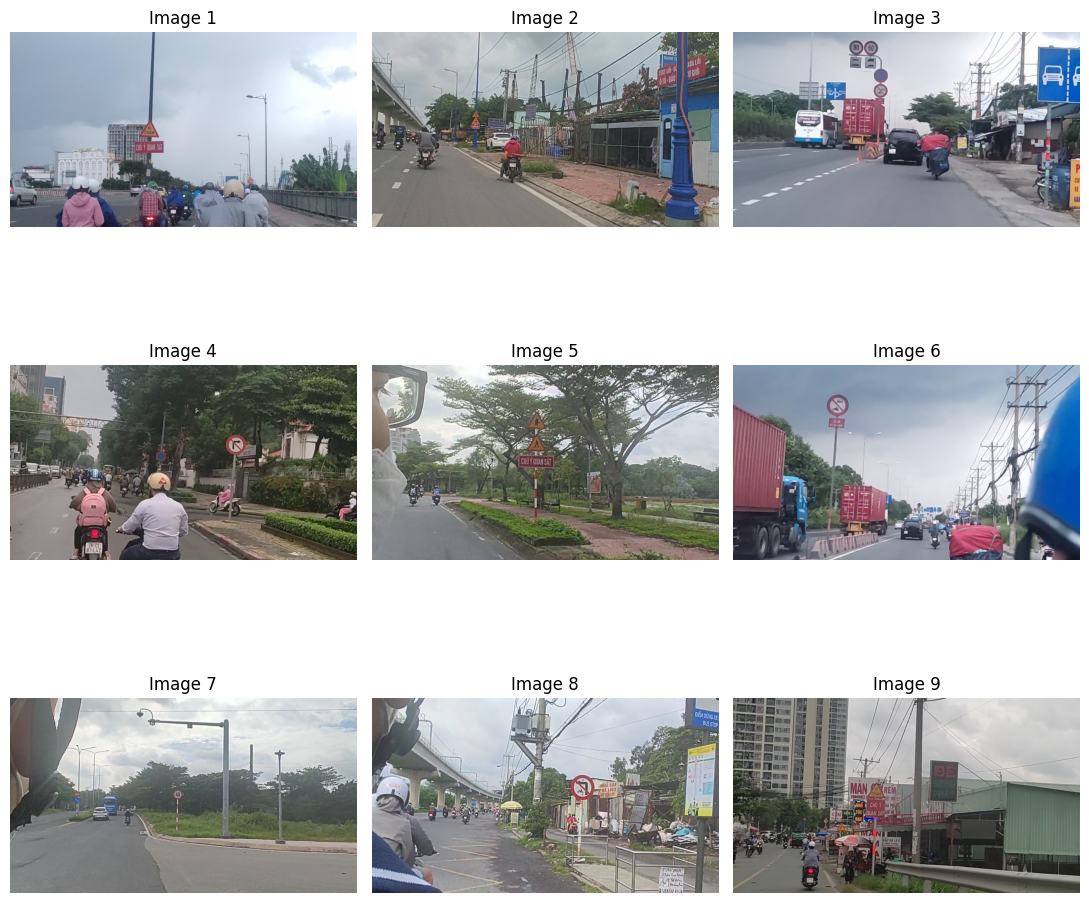

In [7]:
import os
import random
import matplotlib.pyplot as plt

# Correct dataset path
Image_dir = "/content/dataset/archive/images"

# Filter only image files
image_files = [f for f in os.listdir(Image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Ensure we sample only available images
num_samples = min(9, len(image_files))  # Prevent sampling errors

if num_samples == 0:
    print("No images found in the dataset!")
else:
    rand_images = random.sample(image_files, num_samples)

    # Plot the images
    fig, axes = plt.subplots(3, 3, figsize=(11, 11))

    for i in range(num_samples):
        image_path = os.path.join(Image_dir, rand_images[i])
        image = plt.imread(image_path)

        ax = axes[i // 3, i % 3]
        ax.imshow(image)
        ax.set_title(f'Image {i+1}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [12]:
image = cv2.imread("/content/dataset/archive/images/0001.jpg")
h, w, c = image.shape
print(f"The image has dimensions {w}x{h} and {c} channels.")

The image has dimensions 960x540 and 3 channels.


# Image Instance

100%|██████████| 6.25M/6.25M [00:00<00:00, 110MB/s]



image 1/1 /content/dataset/archive/images/0012.jpg: 384x640 10 persons, 3 cars, 2 motorcycles, 1 clock, 54.8ms
Speed: 11.7ms preprocess, 54.8ms inference, 350.0ms postprocess per image at shape (1, 3, 384, 640)


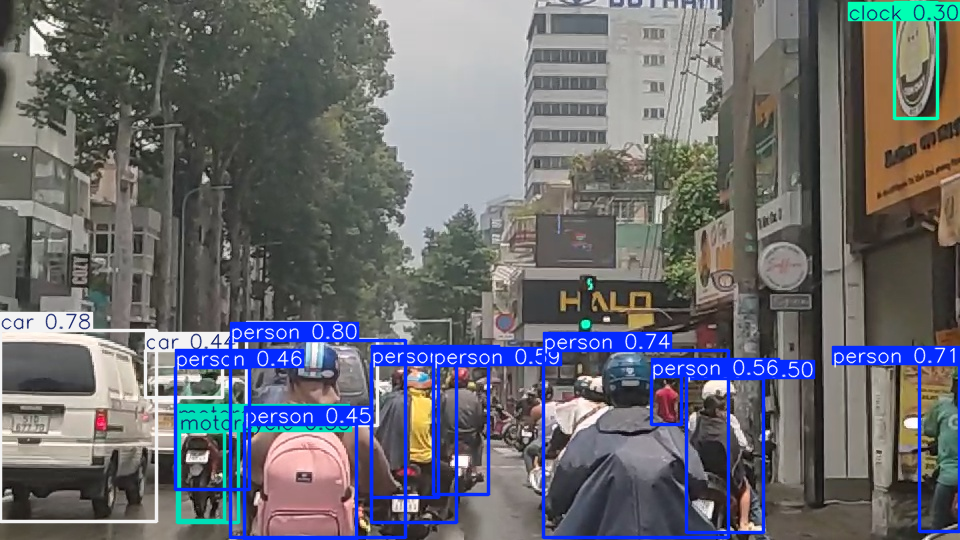

In [9]:
# Use a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Use the model to detect object
image = "/content/dataset/archive/images/0012.jpg"
result_predict = model.predict(source = image, imgsz=(640))

# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))


image 1/1 /content/dataset/archive/images/0156.jpg: 384x640 2 cars, 8.0ms
Speed: 3.4ms preprocess, 8.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


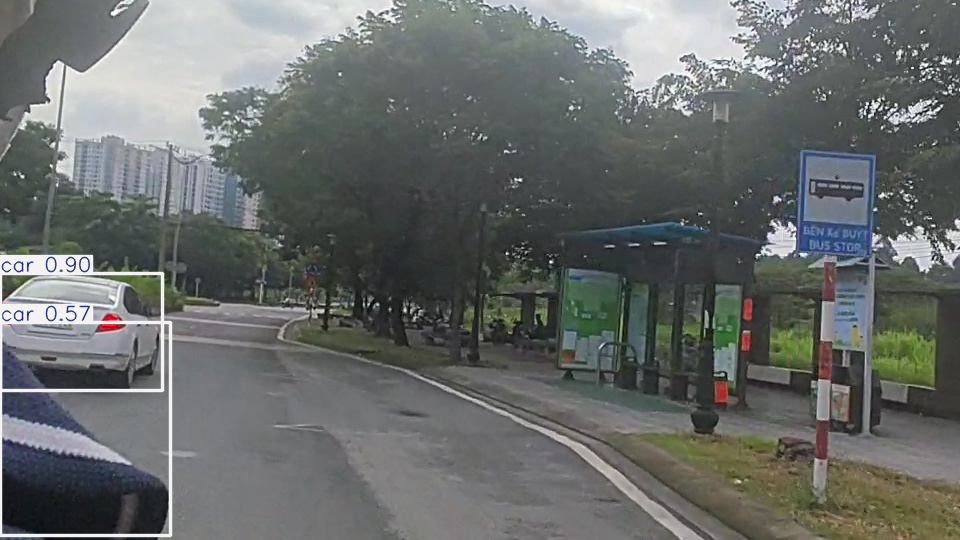

In [11]:
# Use a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Use the model to detect object
image = "/content/dataset/archive/images/0156.jpg"
result_predict = model.predict(source = image, imgsz=(640))

# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

# Train for traffic sign

In [13]:
!pip install --upgrade ultralytics ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 11.4 MB/s eta 0:00:00


In [14]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

In [16]:
dataset_path = "/content/dataset/archive/images"
output_path = "/content/dataset/archive/split_dataset"
os.makedirs(output_path, exist_ok=True)

In [17]:
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
print(f"Total images found: {len(image_files)}")
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_files, temp_files = train_test_split(image_files, test_size=(val_ratio + test_ratio), random_state=42)

val_files, test_files = train_test_split(temp_files, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)
print(f"Train: {len(train_files)}, Validation: {len(val_files)}, Test: {len(test_files)}")

Total images found: 3216
Train: 2251, Validation: 482, Test: 483


In [23]:
import os
import shutil

def copy_files(file_list, image_dest_folder, label_dest_folder, image_src_folder, label_src_folder):
    os.makedirs(image_dest_folder, exist_ok=True)
    os.makedirs(label_dest_folder, exist_ok=True)

    for file in file_list:
        # Copy image
        shutil.copy(os.path.join(image_src_folder, file), os.path.join(image_dest_folder, file))

        # Copy corresponding label file (same name but .txt extension)
        label_file = file.replace(".jpg", ".txt").replace(".png", ".txt")
        label_src_path = os.path.join(label_src_folder, label_file)
        if os.path.exists(label_src_path):  # Check if label exists
            shutil.copy(label_src_path, os.path.join(label_dest_folder, label_file))

# Define source and destination paths
image_folder = "/content/dataset/archive/images"
label_folder = "/content/dataset/archive/labels"
output_path = "/content/dataset/archive/use"

# Split files into train, val, and test
copy_files(train_files, os.path.join(output_path, "train/images"), os.path.join(output_path, "train/labels"), image_folder, label_folder)
copy_files(val_files, os.path.join(output_path, "val/images"), os.path.join(output_path, "val/labels"), image_folder, label_folder)
copy_files(test_files, os.path.join(output_path, "test/images"), os.path.join(output_path, "test/labels"), image_folder, label_folder)

print("✅ Data successfully split into train, val, and test sets!")

✅ Data successfully split into train, val, and test sets!


In [27]:
print("Train images:", len(os.listdir(os.path.join(output_path, "train/images"))))
print("Train labels:", len(os.listdir(os.path.join(output_path, "train/labels"))))

print("Validation images:", len(os.listdir(os.path.join(output_path, "val/images"))))
print("Validation labels:", len(os.listdir(os.path.join(output_path, "val/labels"))))

print("Test images:", len(os.listdir(os.path.join(output_path, "test/images"))))
print("Test labels:", len(os.listdir(os.path.join(output_path, "test/labels"))))

Train images: 2251
Train labels: 2251
Validation images: 482
Validation labels: 482
Test images: 483
Test labels: 483


In [28]:
# Read class names from file
class_file = "/content/dataset/archive/classes_en.txt"  # Update this path if necessary

with open(class_file, "r") as f:
    class_names = [line.strip() for line in f.readlines()]

# Print classes to verify
print(f"✅ Found {len(class_names)} classes:\n", class_names)

✅ Found 54 classes:
 ['Pedestrian Crossing', 'Equal-level Intersection', 'No Entry', 'Right Turn Only', 'Intersection', 'Intersection with a non-priority road', 'Dangerous Turn', 'No Left Turn', 'Bus Stop', 'Roundabout', 'No Stopping and No Parking', 'U-Turn Allowed', 'Lane Allocation', 'No Left Turn for Motorcycles', 'Slow Down', 'No Trucks Allowed', 'Narrow Road on the Right', 'No Passenger Cars and Trucks', 'Height Limit', 'No U-Turn', 'No U-Turn and No Right Turn', 'No Cars Allowed', 'Narrow Road on the Left', 'Uneven Road', 'No Two or Three-wheeled Vehicles', 'Customs Checkpoint', 'Motorcycles Only', 'Obstacle on the Road', 'Children Present', 'Trucks and Containers', 'No Motorcycles Allowed', 'Trucks Only', 'Road with Surveillance Camera', 'No Right Turn', 'Double curve first to right', 'No Containers Allowed', 'No Left or Right Turn', 'No Straight and Right Turn', 'Intersection with T-Junction', 'Speed limit (50km/h)', 'Speed limit (60km/h)', 'Speed limit (80km/h)', 'Speed limit

In [33]:
import yaml

# Define dataset information with correct paths
dataset_info = {
    "path": "/content/dataset/archive/use",
    "train": "train",  # Specify image folder inside train
    "val": "val",  # Specify image folder inside val
    "test": "test",  # Specify image folder inside test
    "nc": 54,  # Number of classes
    "names": [
        "Pedestrian Crossing",
        "Equal-level Intersection",
        "No Entry",
        "Right Turn Only",
        "Intersection",
        "Intersection with a non-priority road",
        "Dangerous Turn",
        "No Left Turn",
        "Bus Stop",
        "Roundabout",
        "No Stopping and No Parking",
        "U-Turn Allowed",
        "Lane Allocation",
        "No Left Turn for Motorcycles",
        "Slow Down",
        "No Trucks Allowed",
        "Narrow Road on the Right",
        "No Passenger Cars and Trucks",
        "Height Limit",
        "No U-Turn",
        "No U-Turn and No Right Turn",
        "No Cars Allowed",
        "Narrow Road on the Left",
        "Uneven Road",
        "No Two or Three-wheeled Vehicles",
        "Customs Checkpoint",
        "Motorcycles Only",
        "Obstacle on the Road",
        "Children Present",
        "Trucks and Containers",
        "No Motorcycles Allowed",
        "Trucks Only",
        "Road with Surveillance Camera",
        "No Right Turn",
        "Double curve first to right",
        "No Containers Allowed",
        "No Left or Right Turn",
        "No Straight and Right Turn",
        "Intersection with T-Junction",
        "Speed limit (50km/h)",
        "Speed limit (60km/h)",
        "Speed limit (80km/h)",
        "Speed limit (40km/h)",
        "Left Turn",
        "Low Clearance",
        "Other Danger",
        "Go Straight",
        "No Parking",
        "Containers Only",
        "No U-Turn for Cars",
        "Level Crossing with Barriers",
        "No U-Turn and No Left Turn",
        "Right Turn Around",
        "Speed Bumps Ahead"
    ]
}

# Save to YAML file
yaml_path = "/content/dataset/archive/data.yaml"
with open(yaml_path, "w") as file:
    yaml.dump(dataset_info, file, default_flow_style=False)

print(f"✅ Dataset YAML file updated at {yaml_path}")


✅ Dataset YAML file updated at /content/dataset/archive/data.yaml


In [34]:
import os
print(os.path.exists("/content/dataset/archive/data.yaml"))


True


In [ ]:
import os
import json
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Define dataset path
dataset_yaml = "/content/dataset/archive/data.yaml"

# Define checkpoint and log directories
checkpoint_dir = "/content/dataset/archive/use/checkpoints"
log_file = "/content/dataset/archive/use/training_metrics.json"

# Create directories if they don't exist
os.makedirs(checkpoint_dir, exist_ok=True)

# List to store training logs
training_logs = []

# Train YOLO for 20 epochs and log results
for epoch in range(1, 51):
    print(f"🚀 Training Epoch {epoch}/10")

    results = model.train(
        data=dataset_yaml,
        epochs=1,  # Train one epoch at a time
        imgsz=640,
        batch=8,
        device="cuda"
    )
    print("Results object:", results)

    # Extract metrics safely
    metrics = results.metrics if hasattr(results, "metrics") else None
    if not metrics:
        print(f"❌ No metrics recorded for epoch {epoch}")
        continue

    epoch_metrics = {
        "epoch": epoch,
        "loss": metrics.box_loss + metrics.cls_loss + metrics.dfl_loss,
        "precision": metrics.precision,
        "recall": metrics.recall,
        "mAP50": metrics.map50,
        "mAP50-95": metrics.map
    }

    # Save logs
    training_logs.append(epoch_metrics)

    # Save checkpoint and log every 5 epochs
    if epoch % 5 == 0:
        checkpoint_path = f"{checkpoint_dir}/yolov8_epoch{epoch}.pt"
        model.export(format="torchscript", save_dir=checkpoint_dir)
        print(f"✅ Checkpoint saved at: {checkpoint_path}")

        # Save metrics to JSON file
        with open(log_file, "w") as f:
            json.dump(training_logs, f, indent=4)
        print(f"📊 Training metrics saved at: {log_file}")


🚀 Training Epoch 1/10
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/archive/data.yaml, epochs=1, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning /content/dataset/archive/use/train/labels.cache... 2251 images, 17 backgrounds, 0 corrupt: 100%|██████████| 2251/2251 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/dataset/archive/use/val/labels.cache... 482 images, 4 backgrounds, 0 corrupt: 100%|██████████| 482/482 [00:00<?, ?it/s]


Plotting labels to runs/detect/train4/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000172, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train4
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

train: Scanning /content/dataset/archive/use/train/labels.cache... 2251 images, 17 backgrounds, 0 corrupt: 100%|██████████| 2251/2251 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/dataset/archive/use/val/labels.cache... 482 images, 4 backgrounds, 0 corrupt: 100%|██████████| 482/482 [00:00<?, ?it/s]


Plotting labels to runs/detect/train4222/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000172, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train4222
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1      1.28G      1.055      3.058     0.8775         19        640: 100%|██████████| 282/282 [01:00<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  74%|███████▍  | 23/31 [00:05<00:01,  4.59it/s]

In [36]:
import json
import matplotlib.pyplot as plt

# Load training metrics
log_file = "/content/dataset/archive/training_metrics.json"

with open(log_file, "r") as f:
    training_logs = json.load(f)

# Extract data
epochs = [log["epoch"] for log in training_logs]
#losses = [log["loss"] for log in training_logs]
precision = [log["precision(B)"] for log in training_logs]
recall = [log["recall(B)"] for log in training_logs]
mAP50s = [log["mAP50"] for log in training_logs]
mAP50_95s = [log["mAP50-95"] for log in training_logs]

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/archive/training_metrics.json'